## 02 — Phase 1: Train on Synthetic Data

### 0. Setup

In [1]:
# Core imports
from pathlib import Path
import torch

# -- Project root --------------------------------------------------------------
# Resolve to absolute. Ultralytics 8.4.39+ prepends a `runs/` dir to relative
# `project=` paths, which silently saved Phase 1 weights to
# `runs/data/noodles_training/...` instead of `data/noodles_training/...`.
# Absolute paths bypass that.
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = (NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR).resolve()
print(f"Project root: {PROJECT_ROOT}")

# -- Paths (all under data/) ---------------------------------------------------
DATA_DIR       = PROJECT_ROOT / "data"
DATASET_DIR    = PROJECT_ROOT / "yolo_dataset"
TRAINING_DIR   = DATA_DIR / "noodles_training"

# -- Runtime device ------------------------------------------------------------
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"Training device: {DEVICE}")

# -- Shared constants ----------------------------------------------------------
PIECE_LABELS     = list("ABCDEFGHIJK")                        # piece classes 0-10
ALL_CLASS_NAMES  = PIECE_LABELS + ["board", "hinge", "pin"]   # 11=board, 12=hinge, 13=pin
NUM_CLASSES      = len(ALL_CLASS_NAMES)                       # 14


yaml_path = DATASET_DIR / "dataset.yaml"
assert yaml_path.exists(), f"Synthetic dataset YAML not found at {yaml_path}. Run notebook 01 first!"
print(f"\nDataset YAML: {yaml_path}")

Project root: C:\Users\abdul\Desktop\noodels
Training device: 0

Dataset YAML: C:\Users\abdul\Desktop\noodels\yolo_dataset\dataset.yaml


### 1. Load Model & Train Phase 1

In [2]:
from ultralytics import YOLO

# ── Model selection ───────────────────────────────────────────────────────────
MODEL_SIZE = 'yolo26n-seg.pt'
model = YOLO(MODEL_SIZE)

print(f"✅ Loaded {MODEL_SIZE} model")
print(f"   Parameters: {sum(p.numel() for p in model.model.parameters()):,}")

✅ Loaded yolo26n-seg.pt model
   Parameters: 3,126,280


In [3]:
# Phase 1: Train on synthetic data
results_phase1 = model.train(
    data=str(yaml_path),
    epochs=100,
    imgsz=640,
    batch=16,
    device=DEVICE,
    workers=2,
    patience=20,
    save=True,
    save_period=25,
    project=str(TRAINING_DIR),
    name='phase1_synthetic',
    exist_ok=True,
    # Augmentation settings
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    degrees=15.0,
    translate=0.1,
    scale=0.4,
    fliplr=0.5,
    flipud=0.1,
    mosaic=0.8,
    mixup=0.1,
    copy_paste=0.2,
)

print("\nPhase 1 training complete (synthetic data)!")

New https://pypi.org/project/ultralytics/8.4.40 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.39  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\abdul\Desktop\noodels\yolo_dataset\dataset.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26n-seg.pt, momentum

### 2. Validate Phase 1

In [4]:
# Load trained model weights for validation (no retraining)
from ultralytics import YOLO

# Path to the best weights from phase 1 training
PHASE1_WEIGHTS = TRAINING_DIR / 'phase1_synthetic' / 'weights' / 'best.pt'
assert PHASE1_WEIGHTS.exists(), f"Trained weights not found at {PHASE1_WEIGHTS}"
model = YOLO(str(PHASE1_WEIGHTS))
print(f"Loaded trained model from: {PHASE1_WEIGHTS}")

# Sanity check: model head must match the 14-class dataset (0..13).
# If you see fewer keys here, the .pt is stale (trained pre-pin) — re-run the
# train cell above so the head is resized.
n_model = len(model.names)
if n_model != NUM_CLASSES:
    raise RuntimeError(
        f"Stale weights: model has {n_model} classes ({list(model.names.values())}) "
        f"but dataset declares {NUM_CLASSES}. Re-run training to resize the head."
    )
print(f"Model classes ({n_model}): {model.names}")

# Phase 1 validation on synthetic val set.
# plots=False sidesteps an Ultralytics PR-curve bug that KeyErrors when val
# labels contain a class id with zero predictions across the whole split
# (e.g. class 12 'hinge' — synthetic data never has it).
metrics_p1 = model.val(
    data=str(yaml_path),
    imgsz=640,
    batch=16,
    device=DEVICE,
    plots=False,
)

print("\n=== Phase 1 Validation Metrics (Synthetic) ===")
print(f"  Box  mAP@0.5:     {metrics_p1.box.map50:.4f}")
print(f"  Box  mAP@0.5:0.95: {metrics_p1.box.map:.4f}")
print(f"  Mask mAP@0.5:     {metrics_p1.seg.map50:.4f}")
print(f"  Mask mAP@0.5:0.95: {metrics_p1.seg.map:.4f}")

# Per-class mAP. Ultralytics returns ap50 indexed by *present* classes only,
# with the actual class ids in ap_class_index — so iterate that, not range(nc).
print("\n=== Per-Class mAP@0.5 (Mask) ===")
ap50 = getattr(metrics_p1.seg, 'ap50', None)
ap_idx = getattr(metrics_p1.seg, 'ap_class_index', None)
if ap50 is not None and ap_idx is not None and len(ap50) > 0:
    for cls_id, ap in zip(ap_idx, ap50):
        name = model.names.get(int(cls_id), str(int(cls_id)))
        print(f"  {int(cls_id):2d} {name}: {ap:.4f}")
    missing = sorted(set(model.names.keys()) - set(int(c) for c in ap_idx))
    if missing:
        print(f"\n  (no val instances for: {[model.names[c] for c in missing]})")
else:
    print("  (no per-class data available)")


Loaded trained model from: C:\Users\abdul\Desktop\noodels\data\noodles_training\phase1_synthetic\weights\best.pt
Model classes (14): {0: 'A_Yellow', 1: 'B_SkyBlue', 2: 'C_DarkBlue', 3: 'D_Green', 4: 'E_Red', 5: 'F_Teal', 6: 'G_Pink', 7: 'H_Purple', 8: 'I_Orange', 9: 'J_DarkRed', 10: 'K_YellowGreen', 11: 'board', 12: 'hinge', 13: 'pin'}
Ultralytics 8.4.39  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLO26n-seg summary (fused): 139 layers, 2,691,614 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2144.2369.1 MB/s, size: 948.8 KB)
val: Scanning C:\Users\abdul\Desktop\noodels\yolo_dataset\labels\val.cache... 480 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 480/480  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 4.0it/s 7.6s0.1s
                   all        480       5863      0.957      0.978      

In [5]:
# Show model summary (architecture and parameters)
model.info()

# Export to ONNX for graphical visualization in Netron:
onnx_path = model.export(format="onnx")
print(f"\nONNX model exported to: {onnx_path}")
print("To view the model graphically, open the .onnx file in https://netron.app or the Netron desktop app.")

YOLO26n-seg summary (fused): 139 layers, 2,691,614 parameters, 0 gradients, 9.0 GFLOPs
Ultralytics 8.4.39  Python-3.11.9 torch-2.11.0+cu128 CPU (11th Gen Intel Core i7-11700K @ 3.60GHz)

PyTorch: starting from 'C:\Users\abdul\Desktop\noodels\data\noodles_training\phase1_synthetic\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 300, 38), (1, 32, 160, 160)) (6.3 MB)

ONNX: starting export with onnx 1.21.0 opset 20...


c:\Users\abdul\Desktop\noodels\.venv\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.91...
ONNX: export success  3.5s, saved as 'C:\Users\abdul\Desktop\noodels\data\noodles_training\phase1_synthetic\weights\best.onnx' (10.6 MB)

Export complete (3.9s)
Results saved to C:\Users\abdul\Desktop\noodels\data\noodles_training\phase1_synthetic\weights
Predict:         yolo predict task=segment model=C:\Users\abdul\Desktop\noodels\data\noodles_training\phase1_synthetic\weights\best.onnx imgsz=640 
Validate:        yolo val task=segment model=C:\Users\abdul\Desktop\noodels\data\noodles_training\phase1_synthetic\weights\best.onnx imgsz=640 data=C:\Users\abdul\Desktop\noodels\yolo_dataset\dataset.yaml  
Visualize:       https://netron.app

ONNX model exported to: C:\Users\abdul\Desktop\noodels\data\noodles_training\phase1_synthetic\weights\best.onnx
To view the model graphically, open the .onnx file in https://netron.app or the Netron desktop app.


In [6]:
# Predict and visualize results on a sample image
import os
from PIL import Image
import matplotlib.pyplot as plt

# Path to a sample image (update this path as needed)
sample_image_path = DATASET_DIR / 'images' / 'train' / sorted(os.listdir(DATASET_DIR / 'images' / 'train'))[0]

# Run prediction
results = model.predict(source=str(sample_image_path), save=False, show=False)

# Visualize prediction
result_img = results[0].plot()
plt.figure(figsize=(8, 8))
plt.imshow(result_img)
plt.axis('off')
plt.title('YOLO Prediction Result')
plt.show()


image 1/1 C:\Users\abdul\Desktop\noodels\yolo_dataset\images\train\000000.png: 640x640 1 H_Purple, 19.6ms
Speed: 4.8ms preprocess, 19.6ms inference, 24.9ms postprocess per image at shape (1, 3, 640, 640)


<Figure size 800x800 with 1 Axes>

In [7]:
# Robust inline display: original, overlay, and per-instance crops
from IPython.display import display
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# choose a sample image
sample_dir = DATASET_DIR / 'images' / 'train'
sample_files = sorted([f for f in os.listdir(sample_dir) if not f.startswith('.')])
assert len(sample_files) > 0, f"No images found in {sample_dir}"
sample_image_path = sample_dir / sample_files[0]
print(f"Using image: {sample_image_path}")

# run prediction (no saving) and get first result
results = model.predict(source=str(sample_image_path), save=False, show=False)
res = results[0]

# get plotted overlay (ndarray or PIL.Image)
try:
    overlay = res.plot()
except Exception as e:
    print('res.plot() failed:', e)
    overlay = None

# load original image as PIL
orig = Image.open(sample_image_path).convert('RGB')

# display original and overlay side-by-side
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(orig)
plt.title('Original')
plt.axis('off')

if overlay is not None:
    if isinstance(overlay, np.ndarray):
        overlay_img = Image.fromarray(overlay)
    else:
        overlay_img = overlay
    plt.subplot(1,2,2)
    plt.imshow(overlay_img)
    plt.title('YOLO Overlay')
    plt.axis('off')
else:
    plt.subplot(1,2,2)
    plt.text(0.5,0.5,'Overlay unavailable',ha='center',va='center')
    plt.axis('off')

plt.show()

# show per-instance crops (boxes and class names) if available
try:
    boxes = getattr(res, 'boxes', None)
    if boxes is not None and len(boxes) > 0:
        # boxes.xyxy may be torch tensor or ndarray
        xyxy = None
        try:
            xyxy = boxes.xyxy.numpy()  # if torch->numpy
        except Exception:
            try:
                xyxy = np.array(boxes.xyxy)
            except Exception:
                xyxy = None

        names = getattr(model, 'names', None) or getattr(res, 'names', None) or {}
        # create a grid of crops (max 6)
        n_show = min(6, len(boxes))
        plt.figure(figsize=(12,3))
        for i in range(n_show):
            if xyxy is None:
                crop = orig
                title = 'box coords unavailable'
            else:
                x1,y1,x2,y2 = map(int, xyxy[i][:4])
                crop = orig.crop((x1,y1,x2,y2))
                cls = None
                try:
                    cls = int(boxes.cls[i].item()) if hasattr(boxes, 'cls') else None
                except Exception:
                    cls = None
                title = f"{names.get(cls, cls)}" if cls is not None else 'instance'
            plt.subplot(1,n_show,i+1)
            plt.imshow(crop)
            plt.title(title)
            plt.axis('off')
        plt.show()
    else:
        print('No boxes found to show per-instance crops.')
except Exception as e:
    print('Per-instance display failed:', e)

# (Optional) save overlay image for external viewing
try:
    out_dir = TRAINING_DIR / 'predictions'
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / (sample_image_path.stem + '_overlay.png')
    if overlay is not None:
        overlay_img.save(out_path)
        print(f'Saved overlay to: {out_path}')
except Exception as e:
    print('Could not save overlay:', e)

Using image: C:\Users\abdul\Desktop\noodels\yolo_dataset\images\train\000000.png

image 1/1 C:\Users\abdul\Desktop\noodels\yolo_dataset\images\train\000000.png: 640x640 1 H_Purple, 22.5ms
Speed: 4.2ms preprocess, 22.5ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)


<Figure size 1200x600 with 2 Axes>

C:\Users\abdul\AppData\Local\Temp\ipykernel_71464\2587342267.py:62: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xyxy = np.array(boxes.xyxy)


<Figure size 1200x300 with 1 Axes>

Saved overlay to: C:\Users\abdul\Desktop\noodels\data\noodles_training\predictions\000000_overlay.png


Saved test image to C:\Users\abdul\Desktop\noodels\debug-output\vscode_image_test.png


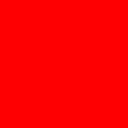

Exists: True Size: 358


In [8]:
# Diagnostic: create and display a simple PNG to test inline image rendering
from PIL import Image
from IPython.display import display, Image as IPImage
import numpy as np
from pathlib import Path

out_path = PROJECT_ROOT / "debug-output" / "vscode_image_test.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
arr = np.zeros((128, 128, 3), dtype=np.uint8)
arr[:] = [255, 0, 0]  # red
img = Image.fromarray(arr)
img.save(out_path)
print('Saved test image to', out_path)
# Try to display inline using IPython.display (this should render in the notebook UI)
display(IPImage(filename=str(out_path)))
# Also check file exists and size for diagnosis
print('Exists:', out_path.exists(), 'Size:', out_path.stat().st_size if out_path.exists() else 'N/A')


In [9]:
# Notebook viewer: display YOLO-format labeled images and segmentation masks inline (with class names from dataset.yaml)
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from PIL import Image
import os
from pathlib import Path
import re

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = Path("..") if NOTEBOOK_DIR.name == "notebooks" else Path(".")
DATASET_DIR = PROJECT_ROOT / "yolo_dataset"

# Load class names from dataset.yaml (fallback to simple parser if PyYAML not installed)
CLASS_NAMES = {}
try:
    import yaml
    yaml_path = DATASET_DIR / 'dataset.yaml'
    if yaml_path.exists():
        content = yaml.safe_load(yaml_path.read_text())
        names_map = content.get('names', {}) or {}
        for k, v in names_map.items():
            try:
                CLASS_NAMES[int(k)] = v
            except Exception:
                CLASS_NAMES[len(CLASS_NAMES)] = v
except Exception:
    # fallback simple parser
    yaml_path = DATASET_DIR / 'dataset.yaml'
    if yaml_path.exists():
        txt = yaml_path.read_text()
        m = re.search(r"names:\n((?:\s+\d+:.*\n)+)", txt)
        if m:
            for line in m.group(1).splitlines():
                line = line.strip()
                if ':' in line:
                    k, v = line.split(':', 1)
                    try:
                        CLASS_NAMES[int(k.strip())] = v.strip()
                    except Exception:
                        pass


def _label_name(cls):
    return CLASS_NAMES.get(cls, str(cls))


def load_yolo_labels(label_path, img_w, img_h):
    boxes = []
    segs = []
    if not label_path.exists():
        return boxes, segs
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            vals = list(map(float, parts))
            cls = int(vals[0])
            cx, cy, w, h = vals[1:5]
            x1 = (cx - w/2) * img_w
            y1 = (cy - h/2) * img_h
            boxes.append((cls, x1, y1, w * img_w, h * img_h))

            if len(vals) > 5:
                poly_vals = vals[5:]
                pts = []
                for i in range(0, len(poly_vals), 2):
                    px = poly_vals[i] * img_w
                    py = poly_vals[i+1] * img_h
                    pts.append((px, py))
                if pts:
                    segs.append((cls, pts))
    return boxes, segs


# simple color palette
PALETTE = [(31,119,180),(255,127,14),(44,160,44),(214,39,40),(148,103,189),(140,86,75),(227,119,194),(127,127,127),(188,189,34),(23,190,207)]
PALETTE = [(c[0]/255.0, c[1]/255.0, c[2]/255.0) for c in PALETTE]


def show_yolo_images(dataset_dir=DATASET_DIR, subset='train', n=6, start=0, show_boxes=True):
    img_dir = Path(dataset_dir) / 'images' / subset
    lbl_dir = Path(dataset_dir) / 'labels' / subset
    files = sorted([f for f in os.listdir(img_dir) if not f.startswith('.')])
    sel = files[start:start+n]
    if not sel:
        print('No images to show')
        return

    cols = min(3, n)
    rows = (len(sel) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax, fn in zip(axes, sel):
        img_path = img_dir / fn
        lbl_path = lbl_dir / (Path(fn).stem + '.txt')

        img = Image.open(img_path).convert('RGB')
        w, h = img.size
        boxes, segs = load_yolo_labels(lbl_path, w, h)

        ax.imshow(img)
        ax.set_title(fn)
        ax.axis('off')

        # draw segments
        for cls, pts in segs:
            color = PALETTE[cls % len(PALETTE)]
            poly = Polygon(pts, closed=True, fill=True, alpha=0.25, edgecolor=color, linewidth=1)
            ax.add_patch(poly)

        # draw boxes
        if show_boxes:
            for cls, x, y, bw, bh in boxes:
                color = PALETTE[cls % len(PALETTE)]
                rect = patches.Rectangle((x, y), bw, bh, linewidth=1.5, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(x, max(0, y-2), f"{cls}:{_label_name(cls)}", color='white', fontsize=8,
                        bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor='none'))

        # if boxes were derived from seg, they might overlap; this keeps both visible

    # hide any unused axes
    for ax in axes[len(sel):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# Example usage:
show_yolo_images(subset='train', n=6, start=0, show_boxes=True)
# show_yolo_images(subset='val', n=6, start=0, show_boxes=True)


<Figure size 1500x1000 with 6 Axes>

In [10]:
show_yolo_images(n=4, start=0)

<Figure size 1500x1000 with 6 Axes>